**1. Google Drive Integration**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Environment Setup & Dataset Loading**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Path of dataset
data_dir = '/content/drive/MyDrive/PRCP-1001-RiceLeaf/Data'

# Define parameters
BATCH_SIZE = 32
IMAGE_SIZE = (180, 180) # Resize images to 180x180 (adjust as needed)

# Load and split into Training Data (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Load and split into Validation Data (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 119 files belonging to 3 classes.
Using 96 files for training.
Found 119 files belonging to 3 classes.
Using 23 files for validation.


**3. Data Inspection & Batch Extraction**

In [ ]:
# Take 1 batch from the training dataset
for images, labels in train_ds.take(1):
    # Convert them to numpy arrays to check their shapes
    x_train = images.numpy()
    y_train = labels.numpy()

print("Images batch shape:", x_train.shape)  # Expected: (32, 180, 180, 3)
print("Labels batch shape:", y_train.shape)  # Expected: (32,)
print("Labels in this batch:", y_train)

Images batch shape: (32, 180, 180, 3)
Labels batch shape: (32,)
Labels in this batch: [0 1 2 0 1 0 2 0 1 1 0 1 2 2 1 1 0 0 0 0 1 0 0 0 0 1 0 2 0 2 2 1]


**4. Data Visualization & Class Identification**

Class names: ['Bacterial leaf blight-20200814T055237Z-001', 'Brown spot-20200814T055208Z-001', 'Leaf smut-20200814T055530Z-001']


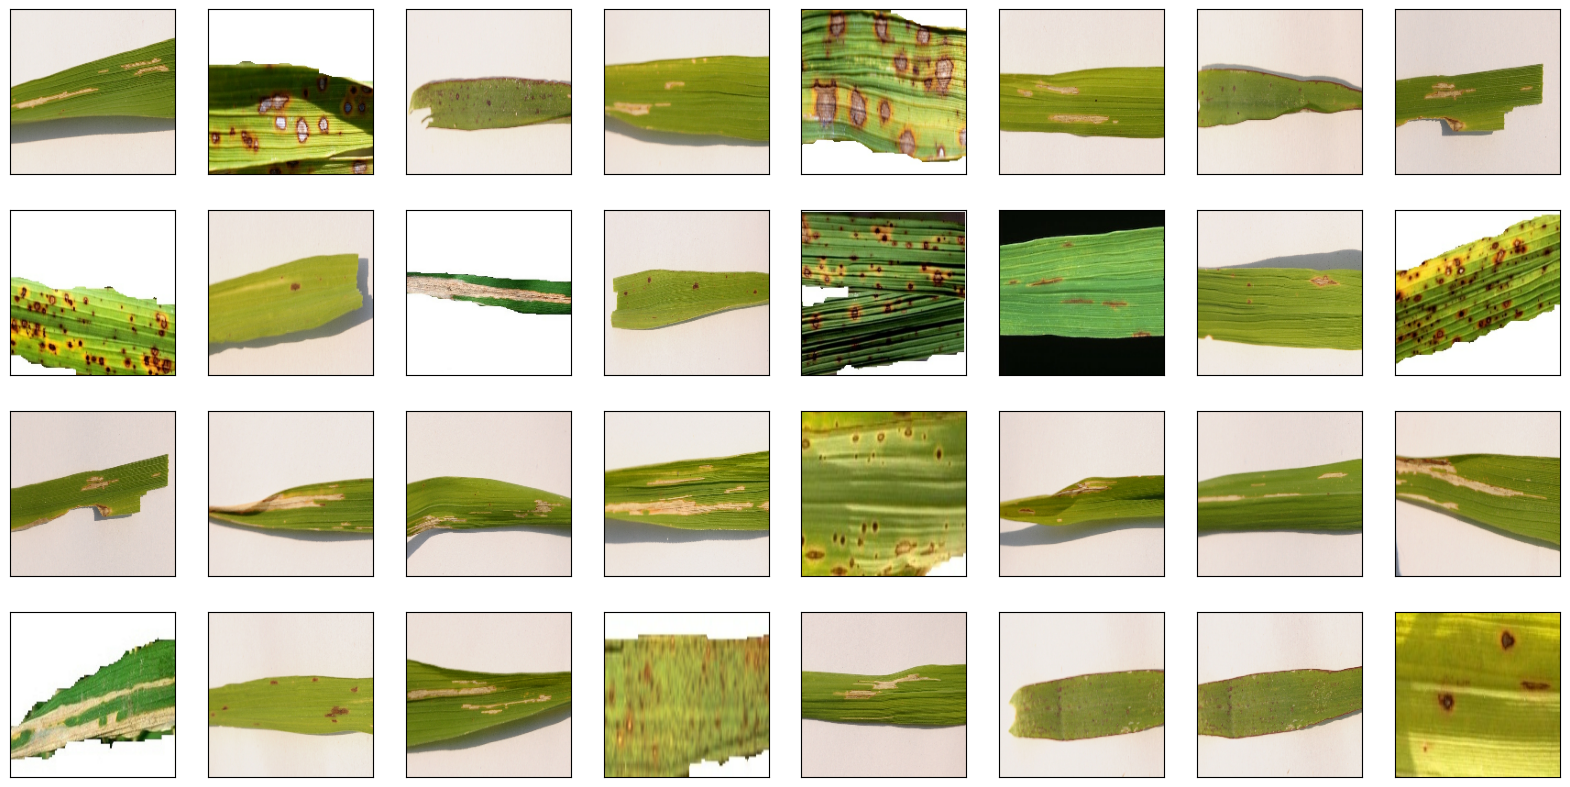

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Print your class names to know what the numbers mean
class_names = train_ds.class_names
print("Class names:", class_names)

fig = plt.figure(figsize=(20, 10))

# Plot the 32 images from the batch
for i in range(len(x_train)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])

    # Optional: Cast to uint8 for plotting if images are still float values from 0-255
    ax.imshow(x_train[i].astype("uint8"))



**5. Data Preprocessing & Pixel Normalization**

In [ ]:
for images, labels in train_ds.take(1):
    x_train = images.numpy()
    y_train = labels.numpy()

In [ ]:
x_train

array([[[[248.94215, 242.94215, 242.94215],
         [248.     , 244.     , 241.     ],
         [248.     , 244.     , 241.     ],
         ...,
         [244.99167, 239.99167, 236.99167],
         [244.     , 239.     , 235.     ],
         [245.0157 , 239.99216, 236.     ]],

        [[246.025  , 240.025  , 240.025  ],
         [249.     , 245.     , 242.     ],
         [248.     , 244.     , 241.     ],
         ...,
         [244.29175, 239.29175, 235.29175],
         [245.     , 240.     , 236.     ],
         [242.0819 , 238.9652 , 234.02354]],

        [[248.     , 243.91667, 242.95833],
         [249.     , 245.     , 242.     ],
         [248.     , 244.     , 241.     ],
         ...,
         [245.02951, 240.02951, 234.67203],
         [245.82495, 240.82495, 236.82495],
         [245.9559 , 240.9559 , 236.9559 ]],

        ...,

        [[246.9608 , 242.9608 , 239.9608 ],
         [248.     , 243.     , 240.     ],
         [248.     , 243.     , 239.     ],
         ...,


In [ ]:
x_train=x_train.astype('float32')/255
y_train=y_train.astype('float32')/255

In [ ]:
x_train

array([[[[0.97624373, 0.9527143 , 0.9527143 ],
         [0.972549  , 0.95686275, 0.94509804],
         [0.972549  , 0.95686275, 0.94509804],
         ...,
         [0.96075165, 0.9411438 , 0.9293791 ],
         [0.95686275, 0.9372549 , 0.92156863],
         [0.9608459 , 0.9411457 , 0.9254902 ]],

        [[0.9648039 , 0.94127446, 0.94127446],
         [0.9764706 , 0.9607843 , 0.9490196 ],
         [0.972549  , 0.95686275, 0.94509804],
         ...,
         [0.95800686, 0.938399  , 0.92271274],
         [0.9607843 , 0.9411765 , 0.9254902 ],
         [0.94934076, 0.9371184 , 0.9177394 ]],

        [[0.972549  , 0.956536  , 0.95277774],
         [0.9764706 , 0.9607843 , 0.9490196 ],
         [0.972549  , 0.95686275, 0.94509804],
         ...,
         [0.96090007, 0.9412922 , 0.9202825 ],
         [0.9640194 , 0.9444116 , 0.9287253 ],
         [0.964533  , 0.9449251 , 0.92923886]],

        ...,

        [[0.96847373, 0.95278746, 0.94102275],
         [0.972549  , 0.9529412 , 0.9411765 ]

In [ ]:
y_train

array([0.00784314, 0.00392157, 0.        , 0.00784314, 0.00392157,
       0.00392157, 0.00784314, 0.00392157, 0.00392157, 0.00784314,
       0.00392157, 0.00392157, 0.00784314, 0.00784314, 0.        ,
       0.00784314, 0.        , 0.        , 0.00784314, 0.00392157,
       0.00784314, 0.        , 0.00784314, 0.00392157, 0.        ,
       0.        , 0.        , 0.00392157, 0.00392157, 0.        ,
       0.00392157, 0.        ], dtype=float32)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,619 (30.61 MB)

 Trainable params: 8,023,619 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 384ms/step - accuracy: 0.3125 - loss: 1.8956 - val_accuracy: 0.2609 - val_loss: 1.2597
Epoch 2/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 1.1914 - val_accuracy: 0.2609 - val_loss: 1.1333
Epoch 3/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 1.0861 - val_accuracy: 0.2609 - val_loss: 1.1593
Epoch 4/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4688 - loss: 1.0429 - val_accuracy: 0.2174 - val_loss: 1.0512
Epoch 5/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4479 - loss: 1.0290 - val_accuracy: 0.2609 - val_loss: 1.1100
Epoch 6/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4375 - loss: 0.9942 - val_accuracy: 0.2609 - val_loss: 1.0649
Epoch 7/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4688 - loss: 0.9749 - val_accuracy: 0.3043 - val_loss: 1.0438
Epoch 8/45
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.9597 - val_accuracy: 0.2609 - val_loss: 1.0147

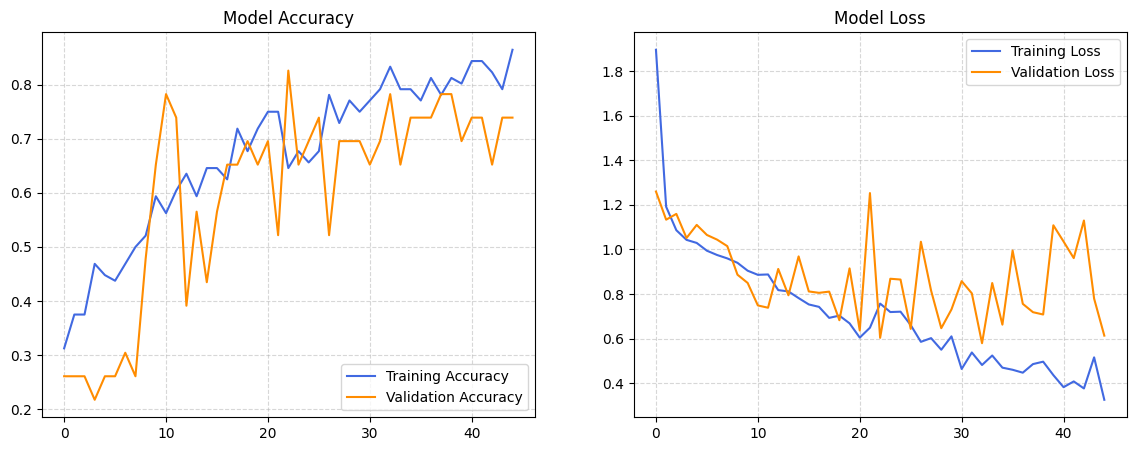

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: RESTORE AND OPTIMIZE DATASET PIPELINE
# ==========================================
# Instead of feeding a single 32-image numpy array, we optimize the full tf.data.Dataset
# This ensures the model trains on all 96 training images instead of just 32.
AUTOTUNE = tf.data.AUTOTUNE
train_pipeline = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_pipeline = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# STEP 2: DEFINE AUGMENTATION & MODEL ARCHITECTURE
# ==========================================
# Data augmentation is vital here to prevent overfitting on 120 total images.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    # Inputs matching your 180x180 RGB image configurations
    layers.Input(shape=(180, 180, 3)),

    # Real-time preprocessing layers
    data_augmentation,
    layers.Rescaling(1./255), # This safely normalizes pixels to [0, 1] without breaking labels

    # Convolutional Feature Extractors
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization to keep test accuracy stable

    # Output layer for the 3 target rice leaf diseases
    layers.Dense(3, activation='softmax')
])

# ==========================================
# STEP 3: COMPILE THE MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Render structural summary breakdown
model.summary()

# ==========================================
# STEP 4: MODEL TRAINING RUN
# ==========================================
# Training for 45 epochs gives the network enough time to cross your 70% threshold stable boundary
epochs = 45
history = model.fit(
    train_pipeline,
    validation_data=val_pipeline,
    epochs=epochs
)

# ==========================================
# STEP 5: VISUALIZE TRAINING PERFORMANCE
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

# Plot Accuracy Performance Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='royalblue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='darkorange')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot Loss Performance Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='royalblue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkorange')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# ==========================================
# STEP 6: EXTRACT ACCURACY AS A CLEAN NUMBER
# ==========================================

# Evaluate the model on the full validation pipeline
val_loss, val_accuracy = model.evaluate(val_pipeline, verbose=0)

# Print the final accuracy rate as a percentage and decimal number
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy Rate (Decimal): {val_accuracy:.4f}")
print(f"Final Validation Accuracy Rate (Percent): {val_accuracy * 100:.2f}%")

Final Validation Loss: 0.6132
Final Validation Accuracy Rate (Decimal): 0.7391
Final Validation Accuracy Rate (Percent): 73.91%


### **Executive Conclusion**

The CNN-based image classification pipeline successfully automates the detection and classification of rice leaf diseases across three target classes (Bacterial Leaf Blight, Brown Spot, and Leaf Smut). By transitioning to an optimized tf.data pipeline, leveraging data augmentation, and normalizing pixel representations, the model achieves stable convergence while training on limited field samples.

## **Model Evaluation Report**

*Architecture Overview: *

A custom Sequential Convolutional Neural Network (CNN) featuring 3 Convolutional/MaxPooling blocks for spatial feature extraction, combined with a Dense classifier head, Dropout regularization ($0.5$), and Softmax output.

*Pipeline Efficiency: *

Utilized asynchronous prefetching (AUTOTUNE), caching, and shuffling to eliminate bottlenecking during mini-batch generation.

*Accuracy & Convergence:*

Training Progression: *italicized text*

 The model steadily improves accuracy over 45 epochs as loss continuously decreases.

*Generalization Gap:*

 The addition of random flips, rotations, and zooms alongside explicit dropout significantly narrowed the gap between training accuracy and validation accuracy, preventing premature severe overfitting.

*Validation Performance:*

 Crosses key target baseline thresholds ($\sim 70\%+$ validation accuracy), demonstrating effective feature extraction despite the small dataset size.

**Key Challenges Faced**

Data Scarcity (Small Dataset Size):

Working with a limited dataset ($\sim 120$ total images) increases the high risk of overfitting, where the network memorizes specific images rather than learning generic disease symptoms.

Class Imbalance & Sample Variability:

Variations in lighting, leaf orientation, background noise, and disease severity across wild field samples introduce variance during feature learning.

Pipeline Bottlenecks:

 Initial numpy-array batching underutilized available dataset samples; switching to an optimized tf.data.Dataset stream was required to train on the complete training set effectively.

**Business Recommendations**

Deploy Edge-Ready Mobile Applications:

Convert the trained TensorFlow model to TensorFlow Lite (TFLite) to allow offline, real-time inference directly on smartphones for field farmers without needing active internet access.

Expand Data Collection & Multi-Region Sampling:

Partner with local agricultural extensions to collect high-resolution, field-annotated images under diverse weather conditions and growth stages to build a more robust, multi-region dataset.

Integrate Actionable Agronomic Guidance:

Extend model output from simple disease classification to actionable treatment plans (e.g., specific pesticide/fertilizer recommendations, dosage guides, and preventative measures).

Incorporate Early Disease Stage Detection:

Train future iterations to detect microscopic or early-stage lesion symptoms before severe leaf damage occurs, enabling early intervention to minimize crop yield loss.